# Sérsic Profile Validation

Visual validation of the JAX Sérsic profile generator against astropy's Sersic2D.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import gammaincinv

import jax.numpy as jnp

from roman_disperser.sersic import (
    make_sersic_image, make_sersic_images,
    catalog_r_eff_to_pixels, sky_pa_to_sca_theta,
)
from astropy.modeling.models import Sersic2D

## 0. b_n Sanity Check

Verify `compute_bn` against well-known values for the three classic Sérsic profiles:

| Profile | n | b_n (exact) |
|---------|---|-------------|
| Gaussian | 0.5 | ln(2) ≈ 0.6931 |
| Exponential | 1.0 | 1.6783 |
| de Vaucouleurs | 4.0 | 7.6692 |

In [ ]:
from roman_disperser.sersic import compute_bn

known = [
    ("Gaussian",       0.5, np.log(2)),   # exact: ln(2)
    ("Exponential",    1.0, 1.6783470),
    ("de Vaucouleurs", 4.0, 7.6692494),
]

print(f"{'Profile':<16s} {'n':>4s} {'Expected':>10s} {'compute_bn':>12s} {'Error':>10s}")
print("-" * 56)
for name, n, expected in known:
    result = float(compute_bn(jnp.float32(n)))
    err = abs(result - expected) / expected
    print(f"{name:<16s} {n:4.1f} {expected:10.7f} {result:12.7f} {err:10.2e}")

## 1. Gallery of Sérsic Profiles

Grid of profiles varying Sérsic index, axis ratio, and position angle.

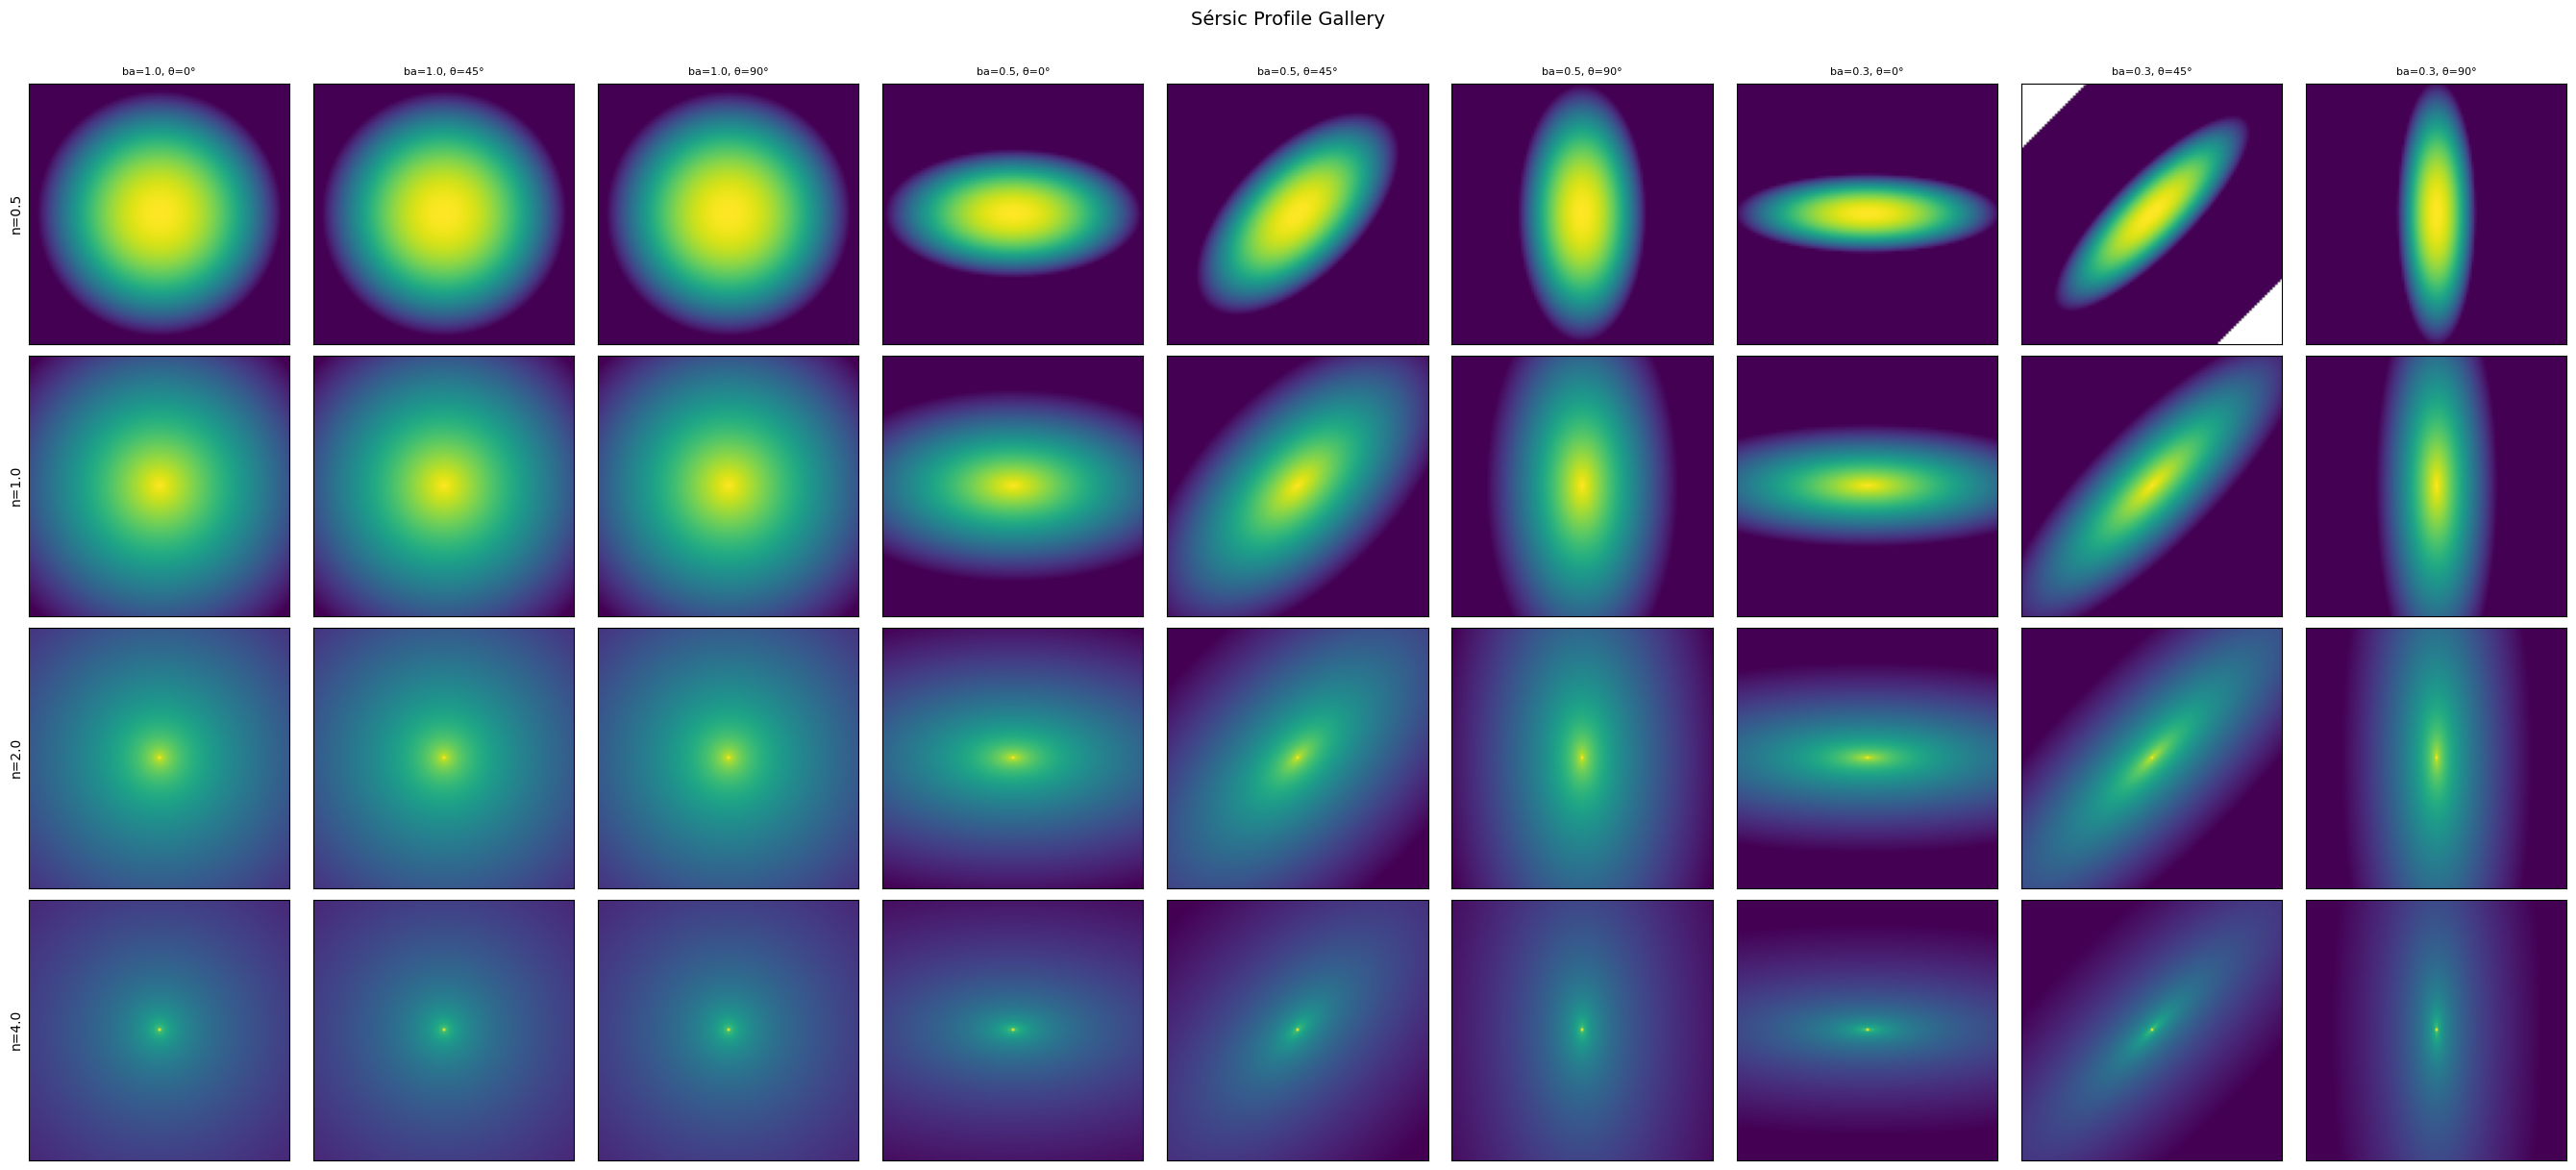

In [6]:
npix = 101
r_eff = 15.0
n_values = [0.5, 1.0, 2.0, 4.0]
ba_values = [1.0, 0.5, 0.3]
theta_values = [0.0, np.pi/4, np.pi/2]

fig, axes = plt.subplots(
    len(n_values), len(ba_values) * len(theta_values),
    figsize=(3 * len(ba_values) * len(theta_values), 3 * len(n_values)),
)

for i, n in enumerate(n_values):
    for j, ba in enumerate(ba_values):
        for k, theta in enumerate(theta_values):
            col = j * len(theta_values) + k
            img = np.array(make_sersic_image(r_eff, n, ba, theta, npix))
            ax = axes[i, col]
            ax.imshow(img, origin='lower', norm=LogNorm(vmin=1e-6, vmax=img.max()))
            if i == 0:
                ax.set_title(f'ba={ba}, θ={np.degrees(theta):.0f}°', fontsize=8)
            if col == 0:
                ax.set_ylabel(f'n={n}', fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])

fig.suptitle('Sérsic Profile Gallery', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Astropy Comparison

Side-by-side images and residual maps for circular and elliptical profiles.

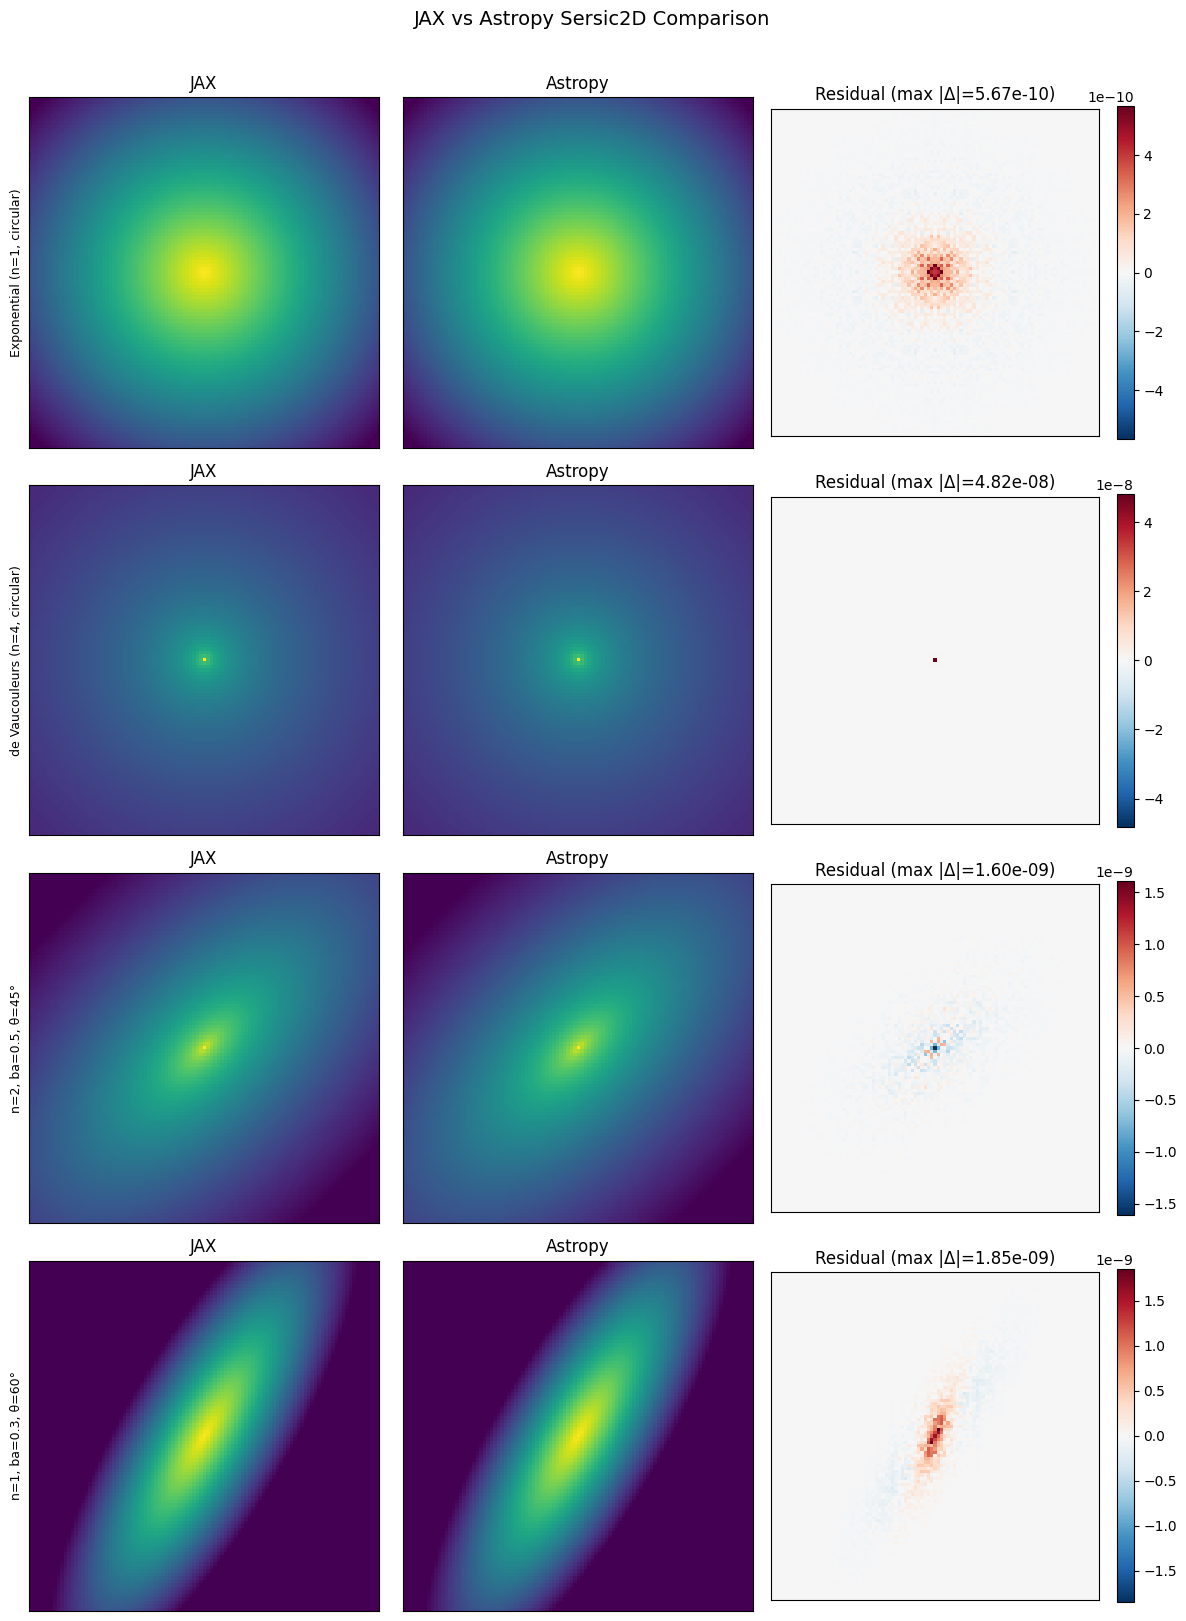

In [7]:
def astropy_sersic(npix, r_eff, n, ba, theta):
    """Generate normalized astropy Sersic2D for comparison."""
    center = (npix - 1) / 2.0
    bn = gammaincinv(2.0 * n, 0.5)
    amplitude = np.exp(bn)
    model = Sersic2D(amplitude=amplitude, r_eff=r_eff, n=n,
                     x_0=center, y_0=center, ellip=1.0 - ba, theta=theta)
    y, x = np.mgrid[0:npix, 0:npix]
    img = model(x, y)
    return img / img.sum()

cases = [
    dict(n=1.0, ba=1.0, theta=0.0, label='Exponential (n=1, circular)'),
    dict(n=4.0, ba=1.0, theta=0.0, label='de Vaucouleurs (n=4, circular)'),
    dict(n=2.0, ba=0.5, theta=np.pi/4, label='n=2, ba=0.5, θ=45°'),
    dict(n=1.0, ba=0.3, theta=np.pi/3, label='n=1, ba=0.3, θ=60°'),
]

fig, axes = plt.subplots(len(cases), 3, figsize=(12, 4 * len(cases)))

for i, case in enumerate(cases):
    img_jax = np.array(make_sersic_image(r_eff, case['n'], case['ba'], case['theta'], npix))
    img_apy = astropy_sersic(npix, r_eff, case['n'], case['ba'], case['theta'])
    residual = img_jax - img_apy

    vmin, vmax = 1e-6, max(img_jax.max(), img_apy.max())

    axes[i, 0].imshow(img_jax, origin='lower', norm=LogNorm(vmin=vmin, vmax=vmax))
    axes[i, 0].set_title('JAX')
    axes[i, 0].set_ylabel(case['label'], fontsize=9)

    axes[i, 1].imshow(img_apy, origin='lower', norm=LogNorm(vmin=vmin, vmax=vmax))
    axes[i, 1].set_title('Astropy')

    im = axes[i, 2].imshow(residual, origin='lower', cmap='RdBu_r',
                            vmin=-np.abs(residual).max(), vmax=np.abs(residual).max())
    axes[i, 2].set_title(f'Residual (max |Δ|={np.abs(residual).max():.2e})')
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046)

    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('JAX vs Astropy Sersic2D Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. PA Transformation Demo

### Sanity check: pointing PA = 60°

At `pointing_pa=60`, the V3IdlYAngle (60°) cancels the pointing PA, so the SCA axes
align with standard sky orientation: +y = North, −x = East.

The formula gives `theta_sca = deg2rad(pa_sky - 60 + 150) = deg2rad(pa_sky + 90)`.

So sky PA=0° (North, major axis points up) → SCA θ=90° (also points up along +y).
The sky and SCA images should look identical.

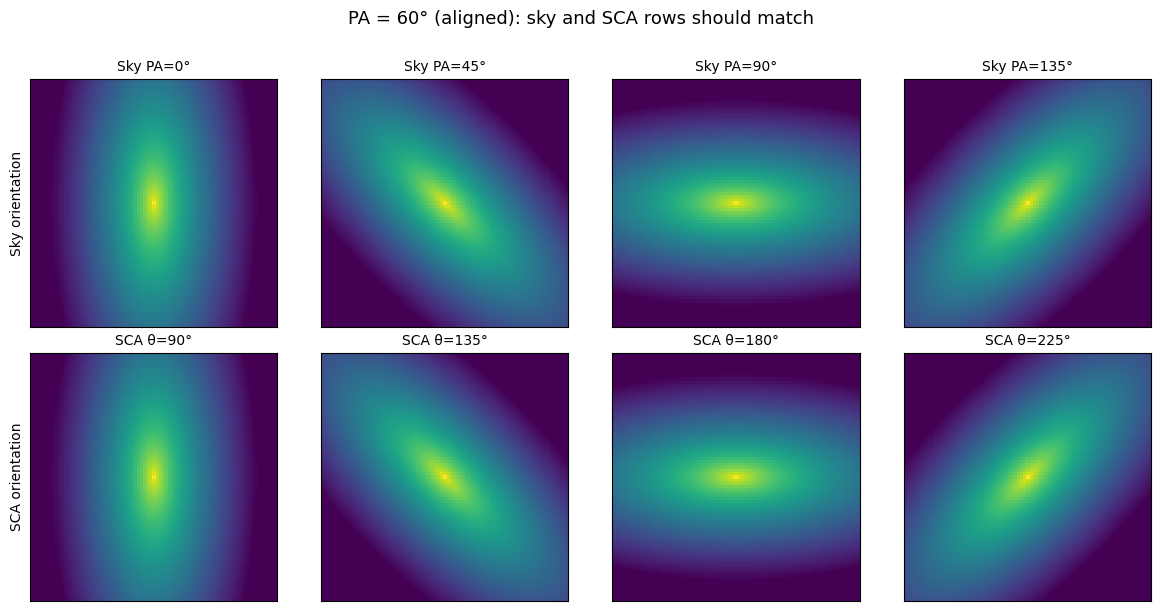

In [9]:
# PA = 60: SCA aligned with sky. Sky and SCA rows should look identical.
pointing_pa_aligned = 60.0

sky_pas = [0.0, 45.0, 90.0, 135.0]
fig, axes = plt.subplots(2, len(sky_pas), figsize=(3 * len(sky_pas), 6))

for j, pa_sky in enumerate(sky_pas):
    # Sky PA is E of N; convert to image theta (CCW from +x) by adding 90°
    # so that PA=0° (North) renders as major axis along +y (up)
    theta_sky = np.deg2rad(pa_sky + 90)
    theta_sca = float(sky_pa_to_sca_theta(pa_sky, pointing_pa_aligned))

    img_sky = np.array(make_sersic_image(12.0, 1.5, 0.4, theta_sky, 81))
    img_sca = np.array(make_sersic_image(12.0, 1.5, 0.4, theta_sca, 81))

    axes[0, j].imshow(img_sky, origin='lower', norm=LogNorm(vmin=1e-6, vmax=img_sky.max()))
    axes[0, j].set_title(f'Sky PA={pa_sky:.0f}°', fontsize=10)
    axes[1, j].imshow(img_sca, origin='lower', norm=LogNorm(vmin=1e-6, vmax=img_sca.max()))
    axes[1, j].set_title(f'SCA θ={np.degrees(theta_sca):.0f}°', fontsize=10)

    for ax in [axes[0, j], axes[1, j]]:
        ax.set_xticks([])
        ax.set_yticks([])

axes[0, 0].set_ylabel('Sky orientation', fontsize=10)
axes[1, 0].set_ylabel('SCA orientation', fontsize=10)
fig.suptitle(f'PA = {pointing_pa_aligned:.0f}° (aligned): sky and SCA rows should match',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### General case: pointing PA = 30°

Now with a non-trivial pointing PA. The SCA images should be rotated by 30° relative to the sky images (since 60° − 30° = 30° of residual rotation).

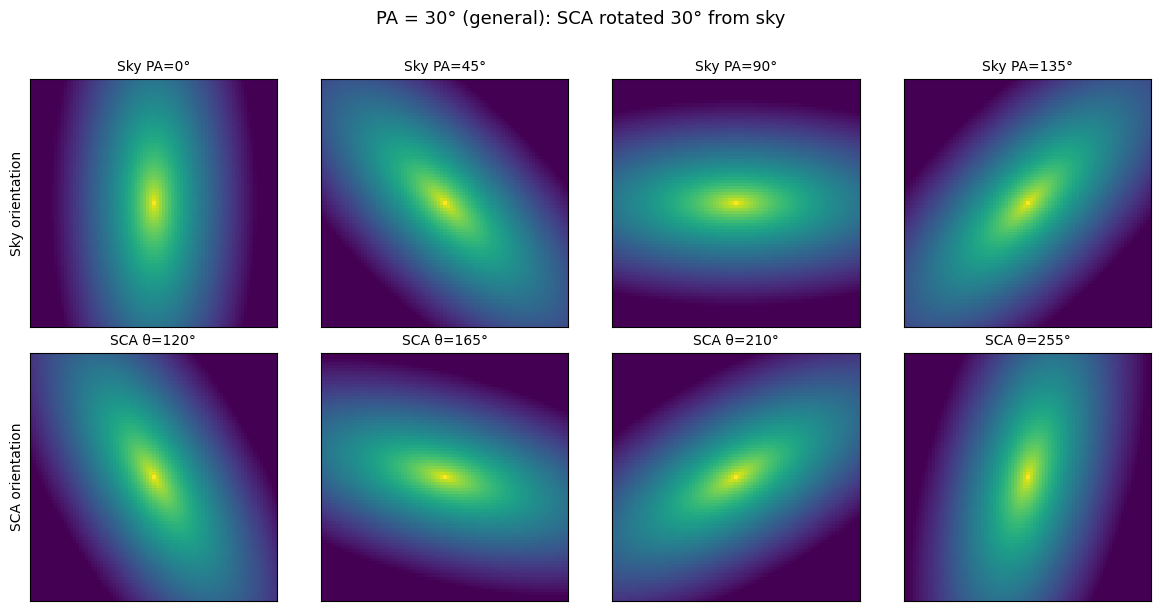

In [10]:
# PA = 30: SCA rotated 30° relative to sky
pointing_pa_general = 30.0

fig, axes = plt.subplots(2, len(sky_pas), figsize=(3 * len(sky_pas), 6))

for j, pa_sky in enumerate(sky_pas):
    theta_sky = np.deg2rad(pa_sky + 90)
    theta_sca = float(sky_pa_to_sca_theta(pa_sky, pointing_pa_general))

    img_sky = np.array(make_sersic_image(12.0, 1.5, 0.4, theta_sky, 81))
    img_sca = np.array(make_sersic_image(12.0, 1.5, 0.4, theta_sca, 81))

    axes[0, j].imshow(img_sky, origin='lower', norm=LogNorm(vmin=1e-6, vmax=img_sky.max()))
    axes[0, j].set_title(f'Sky PA={pa_sky:.0f}°', fontsize=10)
    axes[1, j].imshow(img_sca, origin='lower', norm=LogNorm(vmin=1e-6, vmax=img_sca.max()))
    axes[1, j].set_title(f'SCA θ={np.degrees(theta_sca):.0f}°', fontsize=10)

    for ax in [axes[0, j], axes[1, j]]:
        ax.set_xticks([])
        ax.set_yticks([])

axes[0, 0].set_ylabel('Sky orientation', fontsize=10)
axes[1, 0].set_ylabel('SCA orientation', fontsize=10)
fig.suptitle(f'PA = {pointing_pa_general:.0f}° (general): SCA rotated 30° from sky',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Radial Profiles

Azimuthally-averaged 1D radial profiles vs analytic Sérsic.

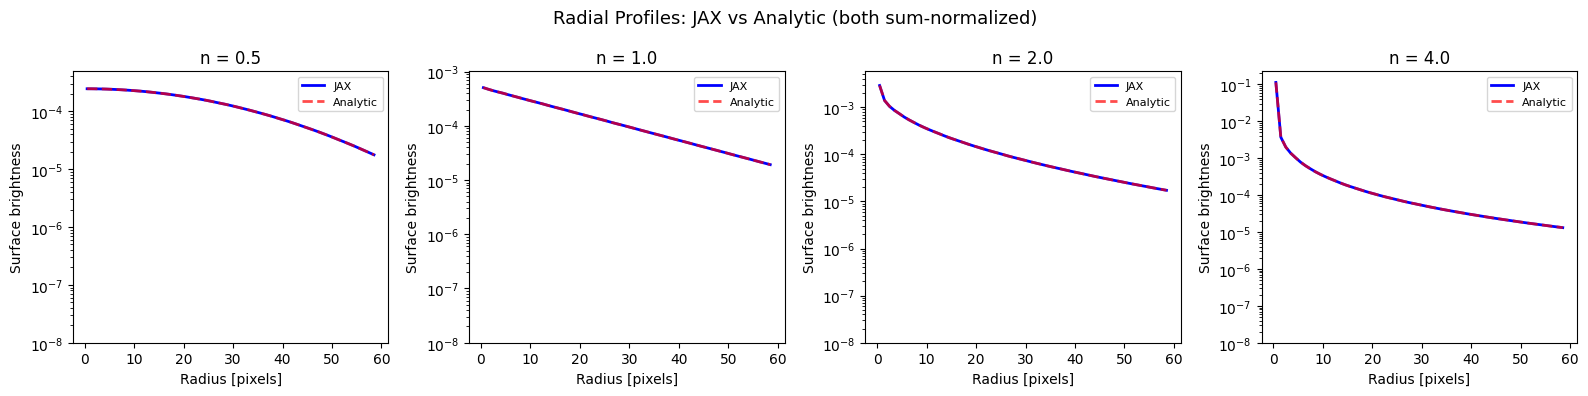

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n in zip(axes, [0.5, 1.0, 2.0, 4.0]):
    npix_rad = 201
    r_eff_rad = 30.0
    img = np.array(make_sersic_image(r_eff_rad, n, 1.0, 0.0, npix_rad))

    # Compute radial profile from image
    center = (npix_rad - 1) / 2.0
    y, x = np.mgrid[0:npix_rad, 0:npix_rad] - center
    r = np.sqrt(x**2 + y**2)

    r_bins = np.arange(0, 60, 1.0)
    r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
    profile = np.zeros(len(r_centers))
    for k in range(len(r_centers)):
        mask = (r >= r_bins[k]) & (r < r_bins[k + 1])
        if mask.any():
            profile[k] = img[mask].mean()

    # Analytic: evaluate the same Sérsic on the pixel grid, normalize to sum=1,
    # then compute the same azimuthal average (apples-to-apples comparison)
    bn = gammaincinv(2.0 * n, 0.5)
    analytic_img = np.exp(-bn * ((r / r_eff_rad) ** (1.0 / n) - 1.0))
    analytic_img /= analytic_img.sum()

    analytic_profile = np.zeros(len(r_centers))
    for k in range(len(r_centers)):
        mask = (r >= r_bins[k]) & (r < r_bins[k + 1])
        if mask.any():
            analytic_profile[k] = analytic_img[mask].mean()

    ax.semilogy(r_centers, profile, 'b-', lw=2, label='JAX')
    ax.semilogy(r_centers, analytic_profile, 'r--', lw=2, label='Analytic', alpha=0.7)
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Radius [pixels]')
    ax.set_ylabel('Surface brightness')
    ax.legend(fontsize=8)
    ax.set_ylim(1e-8, max(profile[0], analytic_profile[0]) * 2)

plt.suptitle('Radial Profiles: JAX vs Analytic (both sum-normalized)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Batch Generation Performance

Time the batch generation of 1000 galaxies.

In [15]:
import time

N = 1000
npix_batch = 61
rng = np.random.default_rng(42)

r_effs = jnp.array(rng.uniform(5.0, 25.0, N), dtype=jnp.float32)
ns = jnp.array(rng.uniform(0.5, 4.0, N), dtype=jnp.float32)
bas = jnp.array(rng.uniform(0.2, 1.0, N), dtype=jnp.float32)
thetas = jnp.array(rng.uniform(0.0, np.pi, N), dtype=jnp.float32)

# Warmup (JIT compile) — must use same batch size to avoid recompilation
_ = make_sersic_images(r_effs, ns, bas, thetas, npix_batch)
_.block_until_ready()

t0 = time.perf_counter()
images = make_sersic_images(r_effs, ns, bas, thetas, npix_batch)
images.block_until_ready()
t1 = time.perf_counter()

print(f"Generated {N} Sérsic images ({npix_batch}×{npix_batch}) in {t1-t0:.3f}s")
print(f"Output shape: {images.shape}")
print(f"All normalized: sum range = [{float(images.sum(axis=(1,2)).min()):.6f}, "
      f"{float(images.sum(axis=(1,2)).max()):.6f}]")

Generated 1000 Sérsic images (61×61) in 0.108s
Output shape: (1000, 61, 61)
All normalized: sum range = [1.000000, 1.000000]
